In [2]:
# ── 0. SETUP ──────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'lightgbm', 'pyarrow', 'kagglehub', 'scikit-learn'], check=True)
import kagglehub, os
kagglehub.login()
BASE = kagglehub.competition_download('mindshift-analytics-haul-mark-challenge')
print('Data at:', BASE)
for f in sorted(os.listdir(BASE)): print(f)

# ── 1. IMPORTS & CONFIG ───────────────────────────────────────────────────────
import gc, warnings, time
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SUBMISSION_PATH = 'submission_v15.csv'
TZ = 'Asia/Kolkata'
SEED = 42
np.random.seed(SEED)

print('Imports done.')

100%|██████████| 1.33G/1.33G [00:07<00:00, 179MB/s]

Extracting files...


Data at: /root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge
fleet.csv
id_mapping.csv
id_mapping_new.csv
mine_001_anonymized.gpkg
mine_002_anonymized.gpkg
rfid_refuels_2026-01-01_2026-02-28.parquet
rfid_refuels_2026-01-01_2026-03-31.parquet
sample_telemetry.csv
smry_feb_train_ordered.csv
smry_jan_train_ordered.csv
smry_mar_train_ordered.csv
telemetry_2026-01-01_2026-01-10.parquet
telemetry_2026-01-11_2026-01-20.parquet
telemetry_2026-01-21_2026-01-31.parquet
telemetry_2026-02-01_2026-02-10.parquet
telemetry_2026-02-11_2026-02-20.parquet
telemetry_2026-02-21_2026-02-28.parquet
telemetry_2026-03-01_2026-03-11.parquet
telemetry_2026-03-12_2026-03-20.parquet
Imports done.


In [3]:
# ── 2. LOAD FLEET & ID MAPPING ────────────────────────────────────────────────
fleet = pd.read_csv(f'{BASE}/fleet.csv')
fleet.columns = [c.lower().strip() for c in fleet.columns]
fleet_dump = fleet[fleet['vehicle'].str.startswith('Dump', na=False)][
    ['vehicle', 'tankcap', 'mine_anon', 'dump_switch']].copy()
fleet_dump['has_dump_switch'] = (~fleet_dump['dump_switch'].isna()).astype('int8')
fleet_dump['tankcap'] = fleet_dump['tankcap'].fillna(fleet_dump['tankcap'].median())

mine_map = {'mine001': 0, 'mine002': 1, 'mine003': 2}
fleet_dump['mine_enc'] = fleet_dump['mine_anon'].map(mine_map).fillna(0).astype('int8')

id_mapping = pd.read_csv(f'{BASE}/id_mapping_new.csv')
id_mapping['date'] = pd.to_datetime(id_mapping['date'])
print(f'Fleet dump vehicles: {len(fleet_dump)}')
print(f'Test rows: {len(id_mapping)}')

Fleet dump vehicles: 43
Test rows: 1735


In [4]:
# ── 3. LOAD SUMMARY FILES (Training Targets) ─────────────────────────────────
def load_smry(path):
    df = pd.read_csv(path)
    df.columns = [c.lower().strip() for c in df.columns]
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['vehicle'].str.startswith('Dump', na=False)].copy()
    df['lph'] = np.where(
        df['runhrs'] > 0.05,
        (df['acons'] / df['runhrs']).clip(0, 200),
        np.nan
    )
    return df

jan = load_smry(f'{BASE}/smry_jan_train_ordered.csv')
feb = load_smry(f'{BASE}/smry_feb_train_ordered.csv')
mar = load_smry(f'{BASE}/smry_mar_train_ordered.csv')

for name, df in [('Jan', jan), ('Feb', feb), ('Mar', mar)]:
    print(f'{name}: {len(df):,} rows | dates: {df["date"].min().date()} → {df["date"].max().date()}')

all_smry = pd.concat([jan, feb, mar], ignore_index=True)
all_smry = all_smry.sort_values(['vehicle', 'shift', 'date']).reset_index(drop=True)
print(f'\nTotal train rows: {len(all_smry):,}')
print(f'Zero acons: {(all_smry["acons"]==0).sum()} ({100*(all_smry["acons"]==0).mean():.1f}%)')

Jan: 1,797 rows | dates: 2026-01-01 → 2026-01-20
Feb: 1,797 rows | dates: 2026-02-01 → 2026-02-20
Mar: 1,050 rows | dates: 2026-03-01 → 2026-03-11

Total train rows: 4,644
Zero acons: 825 (17.8%)


In [5]:
# ── 4. COMPUTE TELEMETRY FEATURES PER VEHICLE-SHIFT-DATE (with cycle proxy and GPS quality) ──
TELEM_COLS = [
    'vehicle', 'ts', 'ignition', 'shift_dpr', 'date_dpr', 'mine_anon',
    'speed', 'disthav', 'altitude', 'analog_input_1',
    'satellites',  # for GPS quality
]

def compute_shift_features(paths, label=''):
    all_chunks = []
    for path in paths:
        fname = os.path.basename(path)
        t0 = time.time()
        available = pq.ParquetFile(path).schema_arrow.names
        cols = [c for c in TELEM_COLS if c in available]
        df = pq.read_table(path, columns=cols).to_pandas()
        df['ts'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert(TZ)
        df = df[df['vehicle'].str.startswith('Dump', na=False)].copy()
        df = df.sort_values(['vehicle', 'ts']).reset_index(drop=True)
        df['date'] = pd.to_datetime(df['date_dpr'])
        df['shift'] = df['shift_dpr']
        if 'speed' not in df.columns: df['speed'] = 0.0
        if 'disthav' not in df.columns: df['disthav'] = 0.0
        if 'altitude' not in df.columns: df['altitude'] = 0.0
        if 'analog_input_1' not in df.columns: df['analog_input_1'] = np.nan
        if 'satellites' not in df.columns: df['satellites'] = np.nan

        df['dt_s'] = (
            df.groupby('vehicle')['ts']
              .transform(lambda x: x.diff().dt.total_seconds().clip(0, 120).fillna(0))
        )
        df['ign']    = (df['ignition'] == 1).astype('int8')
        df['moving'] = ((df['ignition'] == 1) & (df['speed'] > 2)).astype('int8')
        df['idle']   = ((df['ignition'] == 1) & (df['speed'] <= 2)).astype('int8')
        df['dumping']= (df['analog_input_1'] > 2.5).astype('int8')

        # Stop events (moving → stopped)
        df['stopped'] = ((df['ignition'] == 1) & (df['speed'] < 1)).astype('int8')
        df['was_moving'] = df.groupby('vehicle')['moving'].shift(1).fillna(0)
        df['stop_event'] = ((df['was_moving'] == 1) & (df['stopped'] == 1)).astype('int8')

        key = ['vehicle', 'date', 'shift']
        agg = df.groupby(key).agg(
            ignition_on_s = ('dt_s', lambda x: (x * df.loc[x.index, 'ign']).sum()),
            moving_s      = ('dt_s', lambda x: (x * df.loc[x.index, 'moving']).sum()),
            idle_s        = ('dt_s', lambda x: (x * df.loc[x.index, 'idle']).sum()),
            dump_s        = ('dt_s', lambda x: (x * df.loc[x.index, 'dumping']).sum()),
            distance_m    = ('disthav', lambda x: x[df.loc[x.index,'ign']==1].sum()),
            n_pings       = ('ts', 'count'),
            n_good_gps    = ('satellites', lambda x: (x >= 6).sum() if x.notna().any() else 0),
            speed_mean    = ('speed', lambda x: x[x > 2].mean() if (x > 2).any() else 0.0),
            speed_max     = ('speed', 'max'),
            altitude_max  = ('altitude', 'max'),
            altitude_min  = ('altitude', 'min'),
            dump_pings    = ('dumping', 'sum'),
            stop_events   = ('stop_event', 'sum'),
            analog_mean   = ('analog_input_1', lambda x: x.dropna().mean() if x.notna().any() else np.nan),
            analog_max    = ('analog_input_1', lambda x: x.dropna().max() if x.notna().any() else np.nan),
        ).reset_index()

        agg['ignition_on_hrs'] = (agg['ignition_on_s'] / 3600).round(4)
        agg['moving_hrs']      = (agg['moving_s'] / 3600).round(4)
        agg['idle_hrs']        = (agg['idle_s'] / 3600).round(4)
        agg['dump_hrs']        = (agg['dump_s'] / 3600).round(4)
        agg['distance_km']     = (agg['distance_m'] / 1000).round(4)
        agg['altitude_delta']  = (agg['altitude_max'] - agg['altitude_min']).clip(0)
        agg['idle_frac']       = (agg['idle_s'] / (agg['ignition_on_s'] + 1)).clip(0, 1)
        agg['speed_mean']      = agg['speed_mean'].fillna(0)
        agg['dump_count']      = (agg['dump_s'] / 180).round(1)
        agg['cycle_proxy']     = agg['stop_events'].clip(0, 50)
        agg['gps_quality']     = (agg['n_good_gps'] / (agg['n_pings'] + 1)).clip(0, 1)

        if 'mine_anon' in df.columns:
            mine_per_veh = df.drop_duplicates('vehicle')[['vehicle','mine_anon']]
            agg = agg.merge(mine_per_veh, on='vehicle', how='left')

        agg = agg.drop(columns=['ignition_on_s','moving_s','idle_s','dump_s',
                                 'distance_m','altitude_max','altitude_min'], errors='ignore')
        all_chunks.append(agg)
        print(f'  [{label}] {fname}: {len(agg):,} shift-rows  ({time.time()-t0:.1f}s)')
        del df, agg; gc.collect()

    result = pd.concat(all_chunks, ignore_index=True)
    result = result.groupby(['vehicle','date','shift'], as_index=False).first()
    print(f'  [{label}] Total: {len(result):,} rows')
    return result

TRAIN_TELEM = [
    f'{BASE}/telemetry_2026-01-01_2026-01-10.parquet',
    f'{BASE}/telemetry_2026-01-11_2026-01-20.parquet',
    f'{BASE}/telemetry_2026-02-01_2026-02-10.parquet',
    f'{BASE}/telemetry_2026-02-11_2026-02-20.parquet',
    f'{BASE}/telemetry_2026-03-01_2026-03-11.parquet',
]
TEST_TELEM = [
    f'{BASE}/telemetry_2026-01-21_2026-01-31.parquet',
    f'{BASE}/telemetry_2026-02-21_2026-02-28.parquet',
    f'{BASE}/telemetry_2026-03-12_2026-03-20.parquet',
]

print('Processing TRAIN telemetry...')
telem_train = compute_shift_features(TRAIN_TELEM, 'TRAIN')
print()
print('Processing TEST telemetry...')
telem_test = compute_shift_features(TEST_TELEM, 'TEST')

Processing TRAIN telemetry...
  [TRAIN] telemetry_2026-01-01_2026-01-10.parquet: 870 shift-rows  (20.0s)
  [TRAIN] telemetry_2026-01-11_2026-01-20.parquet: 900 shift-rows  (10.6s)
  [TRAIN] telemetry_2026-02-01_2026-02-10.parquet: 900 shift-rows  (11.8s)
  [TRAIN] telemetry_2026-02-11_2026-02-20.parquet: 900 shift-rows  (11.9s)
  [TRAIN] telemetry_2026-03-01_2026-03-11.parquet: 990 shift-rows  (11.7s)
  [TRAIN] Total: 4,590 rows

Processing TEST telemetry...
  [TEST] telemetry_2026-01-21_2026-01-31.parquet: 957 shift-rows  (11.3s)
  [TEST] telemetry_2026-02-21_2026-02-28.parquet: 720 shift-rows  (9.0s)
  [TEST] telemetry_2026-03-12_2026-03-20.parquet: 810 shift-rows  (8.7s)
  [TEST] Total: 2,520 rows


In [6]:
# ── 5. MINE-LEVEL CONTEXT FEATURES (same as v13) ─────────────────────────────
def compute_mine_context(telem_df, label=''):
    t = telem_df.copy()
    if 'mine_anon' not in t.columns:
        t = t.merge(fleet_dump[['vehicle','mine_anon']], on='vehicle', how='left')
    mine_ctx = t.groupby(['mine_anon', 'date', 'shift']).agg(
        mine_avg_ign_hrs  = ('ignition_on_hrs', 'mean'),
        mine_sum_ign_hrs  = ('ignition_on_hrs', 'sum'),
        mine_n_active     = ('ignition_on_hrs', lambda x: (x > 0.1).sum()),
        mine_n_total      = ('ignition_on_hrs', 'count'),
        mine_avg_dist_km  = ('distance_km', 'mean'),
        mine_avg_moving   = ('moving_hrs', 'mean'),
    ).reset_index()
    mine_ctx['mine_active_frac'] = mine_ctx['mine_n_active'] / (mine_ctx['mine_n_total'] + 0.01)
    print(f'  [{label}] mine context rows: {len(mine_ctx)}')
    return mine_ctx

mine_ctx_train = compute_mine_context(telem_train, 'TRAIN')
mine_ctx_test  = compute_mine_context(telem_test,  'TEST')
mine_ctx_cols = ['mine_avg_ign_hrs','mine_sum_ign_hrs','mine_n_active',
                 'mine_n_total','mine_avg_dist_km','mine_avg_moving','mine_active_frac']

  [TRAIN] mine context rows: 306
  [TEST] mine context rows: 168


In [7]:
# ── 6. MERGE FEATURES INTO TRAINING DATA (including new fuel level stats) ────
# Fuel level stats per vehicle-shift (from summary)
smry_fuel_stats = all_smry.groupby(['vehicle', 'shift']).agg(
    h_mean_initlev = ('initlev', 'mean'),
    h_mean_endlev  = ('endlev',  'mean'),
    h_mean_arefill = ('arefill', 'mean'),
    h_pct_refill   = ('arefill', lambda x: (x > 0).mean()),
).reset_index()

all_smry['month']        = all_smry['date'].dt.month.astype('int8')
all_smry['day_of_week']  = all_smry['date'].dt.dayofweek.astype('int8')
all_smry['day_of_month'] = all_smry['date'].dt.day.astype('int8')
all_smry['is_weekend']   = (all_smry['date'].dt.dayofweek >= 5).astype('int8')
all_smry['shift_enc']    = all_smry['shift'].map({'A':0,'B':1,'C':2}).fillna(0).astype('int8')
all_smry['vehicle_num']  = all_smry['vehicle'].str.extract(r'(\d+)')[0].astype('int32')

# Merge fleet
all_smry = all_smry.merge(fleet_dump[['vehicle','tankcap','mine_enc','has_dump_switch']], on='vehicle', how='left')
all_smry['mine_enc2'] = all_smry['mine'].map(mine_map).fillna(0).astype('int8')
all_smry['mine_enc']  = all_smry['mine_enc2'].fillna(all_smry['mine_enc'])

# Merge telemetry
telem_cols = ['vehicle','date','shift','ignition_on_hrs','moving_hrs','idle_hrs','dump_hrs',
              'distance_km','n_pings','speed_mean','speed_max','altitude_delta','idle_frac',
              'dump_count','dump_pings','stop_events','cycle_proxy','gps_quality','analog_mean','analog_max']
telem_feat = telem_train[[c for c in telem_cols if c in telem_train.columns]]
all_smry = all_smry.merge(telem_feat, on=['vehicle','date','shift'], how='left')

# Merge mine context
all_smry = all_smry.merge(fleet_dump[['vehicle','mine_anon']].rename(columns={'mine_anon':'mine_anon_fleet'}), on='vehicle', how='left')
mine_rev_map = {v: k for k, v in mine_map.items()}
all_smry['mine_anon_smry'] = all_smry['mine_enc'].map(mine_rev_map)
all_smry['mine_anon_join'] = all_smry['mine_anon_smry'].fillna(all_smry['mine_anon_fleet'])
all_smry = all_smry.merge(mine_ctx_train.rename(columns={'mine_anon': 'mine_anon_join'}), on=['mine_anon_join','date','shift'], how='left')

# Merge fuel level stats
all_smry = all_smry.merge(smry_fuel_stats, on=['vehicle','shift'], how='left')

# Fill missing telemetry
for col in ['ignition_on_hrs','moving_hrs','idle_hrs','dump_hrs','distance_km','n_pings',
           'speed_mean','speed_max','altitude_delta','idle_frac','dump_count','dump_pings',
           'stop_events','cycle_proxy','gps_quality']:
    if col in all_smry.columns:
        all_smry[col] = all_smry[col].fillna(0)

for col in mine_ctx_cols:
    if col in all_smry.columns:
        all_smry[col] = all_smry[col].fillna(0)

n_with_telem = all_smry['ignition_on_hrs'].notna().sum()
print(f'Train rows with telemetry: {n_with_telem} / {len(all_smry)} ({100*n_with_telem/len(all_smry):.1f}%)')
print('Training shape after merges:', all_smry.shape)

Train rows with telemetry: 4644 / 4644 (100.0%)
Training shape after merges: (4644, 51)


In [8]:
# ── 7. HISTORICAL STATISTICS (per vehicle-shift, vehicle, vehicle-shift-month) ──
def compute_hist_stats(smry):
    s = smry.copy()
    s['month'] = s['date'].dt.month
    def safe_mean(x): return x[x>0].mean() if (x>0).any() else 0.0
    def lph_mean(x): return x.dropna().clip(0,150).mean() if x.notna().any() else 45.0

    vs = s.groupby(['vehicle','shift']).agg(
        h_mean          = ('acons',  'mean'),
        h_median        = ('acons',  'median'),
        h_std           = ('acons',  'std'),
        h_p25           = ('acons',  lambda x: x.quantile(0.25)),
        h_p75           = ('acons',  lambda x: x.quantile(0.75)),
        h_p90           = ('acons',  lambda x: x.quantile(0.90)),
        h_pct_active    = ('acons',  lambda x: (x>0).mean()),
        h_active_mean   = ('acons',  safe_mean),
        h_mean_rh       = ('runhrs', 'mean'),
        h_median_rh     = ('runhrs', 'median'),
        h_mean_lph      = ('lph',    lph_mean),
        h_n             = ('acons',  'count'),
        h_mean_ign_hrs  = ('ignition_on_hrs', 'mean'),
        h_mean_dist_km  = ('distance_km', 'mean'),
        h_mean_dumps    = ('dump_count',  'mean'),
    ).reset_index()
    vs['h_std'] = vs['h_std'].fillna(0)
    vs['h_cv']  = vs['h_std'] / (vs['h_mean'] + 1)

    veh = s.groupby('vehicle').agg(
        v_mean          = ('acons',  'mean'),
        v_pct_active    = ('acons',  lambda x: (x>0).mean()),
        v_mean_rh       = ('runhrs', 'mean'),
        v_mean_lph      = ('lph',    lph_mean),
        v_mean_ign      = ('ignition_on_hrs', 'mean'),
        v_mean_dist     = ('distance_km', 'mean'),
    ).reset_index()

    vsm = s.groupby(['vehicle','shift','month']).agg(
        vsm_mean    = ('acons',  'mean'),
        vsm_mean_rh = ('runhrs', 'mean'),
        vsm_pct     = ('acons',  lambda x: (x>0).mean()),
        vsm_mean_lph= ('lph',    lph_mean),
    ).reset_index()

    return vs, veh, vsm

vs, veh, vsm = compute_hist_stats(all_smry)
all_smry = all_smry.merge(vs,  on=['vehicle','shift'],         how='left', suffixes=('','_vs'))
all_smry = all_smry.merge(veh, on='vehicle',                   how='left', suffixes=('','_veh'))
all_smry = all_smry.merge(vsm, on=['vehicle','shift','month'], how='left', suffixes=('','_vsm'))
print('Historical stats merged. Shapes:', all_smry.shape)

Historical stats merged. Shapes: (4644, 77)


In [9]:
# ── 8. LAG & ROLLING FEATURES (including fuel level lags) ────────────────────
all_smry = all_smry.sort_values(['vehicle','shift','date']).reset_index(drop=True)
g = all_smry.groupby(['vehicle','shift'])

# Standard lags
all_smry['lag1_a']   = g['acons'].shift(1)
all_smry['lag2_a']   = g['acons'].shift(2)
all_smry['lag3_a']   = g['acons'].shift(3)
all_smry['lag7_a']   = g['acons'].shift(7)
all_smry['r3_a']     = g['acons'].transform(lambda x: x.rolling(3,  min_periods=1).mean().shift(1))
all_smry['r7_a']     = g['acons'].transform(lambda x: x.rolling(7,  min_periods=1).mean().shift(1))
all_smry['r14_a']    = g['acons'].transform(lambda x: x.rolling(14, min_periods=1).mean().shift(1))
all_smry['exp_a']    = g['acons'].transform(lambda x: x.expanding().mean().shift(1))

# Fuel level lags (NEW)
all_smry['lag1_endlev']  = g['endlev'].shift(1)
all_smry['lag1_initlev'] = g['initlev'].shift(1)
all_smry['r3_endlev']    = g['endlev'].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))

# Runhrs lags
all_smry['lag1_rh']   = g['runhrs'].shift(1)
all_smry['r7_rh']     = g['runhrs'].transform(lambda x: x.rolling(7, min_periods=1).mean().shift(1))
all_smry['lag1_lph']  = g['lph'].shift(1)
all_smry['r7_lph']    = g['lph'].transform(lambda x: x.rolling(7, min_periods=1).mean().shift(1))
all_smry['lag1_ign']  = g['ignition_on_hrs'].shift(1)
all_smry['r7_ign']    = g['ignition_on_hrs'].transform(lambda x: x.rolling(7, min_periods=1).mean().shift(1))

# Fill NaN lags with historical means
for col, fallback in [
    ('lag1_a','h_mean'), ('lag2_a','h_mean'), ('lag3_a','h_mean'), ('lag7_a','h_mean'),
    ('r3_a','h_mean'), ('r7_a','h_mean'), ('r14_a','h_mean'), ('exp_a','h_mean'),
    ('lag1_rh','h_mean_rh'), ('r7_rh','h_mean_rh'),
    ('lag1_lph','h_mean_lph'), ('r7_lph','h_mean_lph'),
    ('lag1_ign','h_mean_ign_hrs'), ('r7_ign','h_mean_ign_hrs'),
    ('lag1_endlev','h_mean_endlev'), ('lag1_initlev','h_mean_initlev'), ('r3_endlev','h_mean_endlev'),
]:
    if col in all_smry.columns and fallback in all_smry.columns:
        all_smry[col] = all_smry[col].fillna(all_smry[fallback]).fillna(0)

print(f'Training shape after lag features: {all_smry.shape}')

Training shape after lag features: (4644, 94)


In [10]:
# ── 9. PHYSICS-BASED FEATURE (leakage fixed for CV, retrained on all for final) ──
from sklearn.linear_model import Ridge

def compute_physics_fuel(df, vehicle_lr_dict, global_lr):
    preds = []
    for _, row in df.iterrows():
        ign = row['ignition_on_hrs']
        if ign <= 0:
            preds.append(0.0)
            continue
        v_id = row['vehicle']
        lr = vehicle_lr_dict.get(v_id)
        if lr is not None:
            pred = lr.predict([[ign]])[0]
        else:
            pred = global_lr.predict([[ign]])[0]
        preds.append(max(0.0, pred))
    return np.array(preds)

# We will fit vehicle_lr on all data for final model, but for CV we fit only on train_mask.
# First, compute global fallback on all active data (for final only)
active_smry = all_smry[all_smry['acons'] > 0].copy()
active_ign = active_smry[active_smry['ignition_on_hrs'] > 0.1].copy()
lr_global_all = Ridge(alpha=1.0)
lr_global_all.fit(active_ign[['ignition_on_hrs']].values, active_ign['acons'].values)

# Per-vehicle models on all data (for final)
vehicle_lr_all = {}
for v_id in active_ign['vehicle'].unique():
    sub = active_ign[active_ign['vehicle'] == v_id]
    if len(sub) >= 8:
        lr_v = Ridge(alpha=1.0)
        lr_v.fit(sub[['ignition_on_hrs']].values, sub['acons'].values)
        vehicle_lr_all[v_id] = lr_v
    else:
        vehicle_lr_all[v_id] = None

print(f'Final physics: vehicles with own LR: {sum(v is not None for v in vehicle_lr_all.values())} / {len(vehicle_lr_all)}')

# Compute physics_fuel for all training (using all-data models) – will be used in final training as a feature
all_smry['physics_fuel'] = compute_physics_fuel(all_smry, vehicle_lr_all, lr_global_all)
print('Physics fuel computed for full training.')

Final physics: vehicles with own LR: 30 / 30
Physics fuel computed for full training.


In [11]:
# ── 10. BUILD TEST FEATURES (same as training but using test telemetry) ──────
test_df = id_mapping.copy()
test_df['month']        = test_df['date'].dt.month.astype('int8')
test_df['day_of_week']  = test_df['date'].dt.dayofweek.astype('int8')
test_df['day_of_month'] = test_df['date'].dt.day.astype('int8')
test_df['is_weekend']   = (test_df['date'].dt.dayofweek >= 5).astype('int8')
test_df['shift_enc']    = test_df['shift'].map({'A':0,'B':1,'C':2}).fillna(0).astype('int8')
test_df['vehicle_num']  = test_df['vehicle'].str.extract(r'(\d+)')[0].astype('int32')

# Fleet features
test_df = test_df.merge(fleet_dump[['vehicle','tankcap','mine_enc','has_dump_switch']], on='vehicle', how='left')

# Historical stats
test_df = test_df.merge(vs,  on=['vehicle','shift'],          how='left')
test_df = test_df.merge(veh, on='vehicle',                    how='left')
test_df = test_df.merge(vsm, on=['vehicle','shift','month'],  how='left')

# Telemetry features
telem_test_feat = telem_test[[c for c in telem_cols if c in telem_test.columns]]
test_df = test_df.merge(telem_test_feat, on=['vehicle','date','shift'], how='left')
test_df['has_real_telem'] = test_df['ignition_on_hrs'].notna().astype('int8')
for col in telem_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(0)

# Mine context for test
test_df = test_df.merge(fleet_dump[['vehicle','mine_anon']].rename(columns={'mine_anon':'mine_anon_fleet'}), on='vehicle', how='left')
test_df['mine_anon_join'] = test_df['mine_enc'].map(mine_rev_map).fillna(test_df['mine_anon_fleet'])
test_df = test_df.merge(mine_ctx_test.rename(columns={'mine_anon': 'mine_anon_join'}), on=['mine_anon_join','date','shift'], how='left')
for col in mine_ctx_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(0)

# Fuel level stats for test (historical averages)
test_df = test_df.merge(smry_fuel_stats, on=['vehicle','shift'], how='left')
for col in ['h_mean_initlev','h_mean_endlev','h_mean_arefill','h_pct_refill']:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(0)

# Physics fuel for test
test_df['physics_fuel'] = compute_physics_fuel(test_df, vehicle_lr_all, lr_global_all)

print(f'Test shape: {test_df.shape}')

Test shape: (1735, 71)


In [12]:
# ── 11. LAG FEATURES FOR TEST (using training lookup) ─────────────────────────
all_smry['date'] = pd.to_datetime(all_smry['date'])
test_df['date']  = pd.to_datetime(test_df['date'])

smry_lookup = all_smry[['vehicle','shift','date','acons','runhrs','lph','ignition_on_hrs',
                        'endlev','initlev']].copy()
smry_lookup = smry_lookup.sort_values(['vehicle','shift','date']).reset_index(drop=True)

def get_lag_features_vectorized(test_df, smry_lookup):
    results = []
    groups = smry_lookup.groupby(['vehicle','shift'])
    for (veh, shift), grp in groups:
        grp = grp.sort_values('date').reset_index(drop=True)
        test_rows = test_df[(test_df['vehicle']==veh) & (test_df['shift']==shift)].copy()
        if len(test_rows) == 0:
            continue
        dates    = pd.to_datetime(grp['date']).values.astype('datetime64[ns]')
        acons_arr= grp['acons'].values
        rh_arr   = grp['runhrs'].values
        lph_arr  = grp['lph'].fillna(45.0).clip(20,150).values
        ign_arr  = grp['ignition_on_hrs'].values
        endlev_arr = grp['endlev'].values
        initlev_arr= grp['initlev'].values

        fa = test_rows['h_mean'].values[0] if 'h_mean' in test_rows.columns else 0
        fr = test_rows['h_mean_rh'].values[0] if 'h_mean_rh' in test_rows.columns else 0
        fl = test_rows['h_mean_lph'].values[0] if 'h_mean_lph' in test_rows.columns else 45.0
        fi = test_rows['h_mean_ign_hrs'].values[0] if 'h_mean_ign_hrs' in test_rows.columns else 0
        fe = test_rows['h_mean_endlev'].values[0] if 'h_mean_endlev' in test_rows.columns else 600

        for _, row in test_rows.iterrows():
            d = pd.to_datetime(row['date']).to_datetime64()
            idx = np.searchsorted(dates, d) - 1
            def get_val(arr, offset, fallback):
                i = idx - offset
                return float(arr[i]) if 0 <= i < len(arr) else fallback
            def rolling(arr, w, fallback):
                start = max(0, idx - w + 1)
                end   = idx + 1
                vals  = arr[start:end]
                return float(vals.mean()) if len(vals) > 0 else fallback
            results.append({
                '_idx':         row.name,
                'lag1_a':       get_val(acons_arr, 0, fa),
                'lag2_a':       get_val(acons_arr, 1, fa),
                'lag3_a':       get_val(acons_arr, 2, fa),
                'lag7_a':       get_val(acons_arr, 6, fa),
                'r3_a':         rolling(acons_arr, 3,  fa),
                'r7_a':         rolling(acons_arr, 7,  fa),
                'r14_a':        rolling(acons_arr, 14, fa),
                'exp_a':        float(acons_arr[:idx+1].mean()) if idx >= 0 else fa,
                'lag1_rh':      get_val(rh_arr, 0, fr),
                'r7_rh':        rolling(rh_arr, 7, fr),
                'lag1_lph':     get_val(lph_arr, 0, fl),
                'r7_lph':       rolling(lph_arr, 7, fl),
                'lag1_ign':     get_val(ign_arr, 0, fi),
                'r7_ign':       rolling(ign_arr, 7, fi),
                'lag1_endlev':  get_val(endlev_arr, 0, fe),
                'lag1_initlev': get_val(initlev_arr, 0, fe),
                'r3_endlev':    rolling(endlev_arr, 3, fe),
            })
    lag_df = pd.DataFrame(results).set_index('_idx')
    return lag_df

print('Computing lag features for test...')
lag_df = get_lag_features_vectorized(test_df, smry_lookup)
test_df = test_df.drop(columns=[c for c in lag_df.columns if c in test_df.columns], errors='ignore')
test_df = test_df.join(lag_df)

for col, fb in [
    ('lag1_a','h_mean'),('lag2_a','h_mean'),('lag3_a','h_mean'),('lag7_a','h_mean'),
    ('r3_a','h_mean'),('r7_a','h_mean'),('r14_a','h_mean'),('exp_a','h_mean'),
    ('lag1_rh','h_mean_rh'),('r7_rh','h_mean_rh'),
    ('lag1_lph','h_mean_lph'),('r7_lph','h_mean_lph'),
    ('lag1_ign','h_mean_ign_hrs'),('r7_ign','h_mean_ign_hrs'),
    ('lag1_endlev','h_mean_endlev'),('lag1_initlev','h_mean_initlev'),('r3_endlev','h_mean_endlev'),
]:
    if col in test_df.columns and fb in test_df.columns:
        test_df[col] = test_df[col].fillna(test_df[fb]).fillna(0)

print(f'Test shape with lags: {test_df.shape}')

Computing lag features for test...
Test shape with lags: (1735, 88)


In [13]:
# ── 12. FEATURE COLUMNS ───────────────────────────────────────────────────────
FEATURE_COLS = [
    # Telemetry
    'ignition_on_hrs', 'moving_hrs', 'idle_hrs', 'distance_km',
    'n_pings', 'speed_mean', 'speed_max', 'altitude_delta',
    'idle_frac', 'dump_count', 'dump_hrs', 'dump_pings',
    'stop_events', 'cycle_proxy', 'gps_quality',
    # Physics
    'physics_fuel',
    # Mine context
    'mine_avg_ign_hrs', 'mine_sum_ign_hrs', 'mine_n_active',
    'mine_n_total', 'mine_avg_dist_km', 'mine_avg_moving', 'mine_active_frac',
    # Time
    'shift_enc', 'month', 'day_of_week', 'day_of_month', 'is_weekend',
    # Vehicle identity
    'vehicle_num', 'mine_enc', 'tankcap', 'has_dump_switch',
    # Historical per vehicle-shift
    'h_mean', 'h_median', 'h_std', 'h_cv', 'h_p25', 'h_p75', 'h_p90',
    'h_pct_active', 'h_active_mean', 'h_mean_rh', 'h_median_rh',
    'h_mean_lph', 'h_n', 'h_mean_ign_hrs', 'h_mean_dist_km', 'h_mean_dumps',
    # Fuel level stats
    'h_mean_initlev', 'h_mean_endlev', 'h_mean_arefill', 'h_pct_refill',
    # Vehicle overall
    'v_mean', 'v_pct_active', 'v_mean_rh', 'v_mean_lph', 'v_mean_ign', 'v_mean_dist',
    # Vehicle-shift-month
    'vsm_mean', 'vsm_mean_rh', 'vsm_pct', 'vsm_mean_lph',
    # Lags
    'lag1_a', 'lag2_a', 'lag3_a', 'lag7_a',
    'r3_a', 'r7_a', 'r14_a', 'exp_a',
    'lag1_rh', 'r7_rh',
    'lag1_lph', 'r7_lph',
    'lag1_ign', 'r7_ign',
    'lag1_endlev', 'lag1_initlev', 'r3_endlev',
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in all_smry.columns and c in test_df.columns]
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Features (79): ['ignition_on_hrs', 'moving_hrs', 'idle_hrs', 'distance_km', 'n_pings', 'speed_mean', 'speed_max', 'altitude_delta', 'idle_frac', 'dump_count', 'dump_hrs', 'dump_pings', 'stop_events', 'cycle_proxy', 'gps_quality', 'physics_fuel', 'mine_avg_ign_hrs', 'mine_sum_ign_hrs', 'mine_n_active', 'mine_n_total', 'mine_avg_dist_km', 'mine_avg_moving', 'mine_active_frac', 'shift_enc', 'month', 'day_of_week', 'day_of_month', 'is_weekend', 'vehicle_num', 'mine_enc', 'tankcap', 'has_dump_switch', 'h_mean', 'h_median', 'h_std', 'h_cv', 'h_p25', 'h_p75', 'h_p90', 'h_pct_active', 'h_active_mean', 'h_mean_rh', 'h_median_rh', 'h_mean_lph', 'h_n', 'h_mean_ign_hrs', 'h_mean_dist_km', 'h_mean_dumps', 'h_mean_initlev', 'h_mean_endlev', 'h_mean_arefill', 'h_pct_refill', 'v_mean', 'v_pct_active', 'v_mean_rh', 'v_mean_lph', 'v_mean_ign', 'v_mean_dist', 'vsm_mean', 'vsm_mean_rh', 'vsm_pct', 'vsm_mean_lph', 'lag1_a', 'lag2_a', 'lag3_a', 'lag7_a', 'r3_a', 'r7_a', 'r14_a', 'exp_a', 'lag1_rh', 'r7_rh',

In [14]:
# ── 13. CV SETUP (with leakage‑free physics for validation) ───────────────────
val_mask   = all_smry['date'] >= pd.Timestamp('2026-03-01')
train_mask = ~val_mask

# For CV, recompute physics_fuel on validation using models fit only on train_mask
active_train_cv = all_smry.loc[train_mask & (all_smry['acons'] > 0) & (all_smry['ignition_on_hrs'] > 0.1)]
vehicle_lr_cv = {}
for v_id in active_train_cv['vehicle'].unique():
    sub = active_train_cv[active_train_cv['vehicle'] == v_id]
    if len(sub) >= 8:
        lr_v = Ridge(alpha=1.0)
        lr_v.fit(sub[['ignition_on_hrs']].values, sub['acons'].values)
        vehicle_lr_cv[v_id] = lr_v
    else:
        vehicle_lr_cv[v_id] = None
lr_global_cv = Ridge(alpha=1.0)
lr_global_cv.fit(active_train_cv[['ignition_on_hrs']].values, active_train_cv['acons'].values)

# Compute physics_fuel for validation using CV models
physics_val_cv = compute_physics_fuel(all_smry.loc[val_mask], vehicle_lr_cv, lr_global_cv)

# Prepare X, y
X_tr  = all_smry.loc[train_mask, FEATURE_COLS].fillna(0).astype('float32')
y_tr  = all_smry.loc[train_mask, 'acons'].astype('float32')
X_val = all_smry.loc[val_mask,   FEATURE_COLS].fillna(0).astype('float32')
y_val = all_smry.loc[val_mask,   'acons'].astype('float32')

print(f'CV Train: {len(X_tr):,}  |  CV Val: {len(X_val):,}')
print(f'Val period: {all_smry.loc[val_mask, "date"].min().date()} → {all_smry.loc[val_mask, "date"].max().date()}')

CV Train: 3,594  |  CV Val: 1,050
Val period: 2026-03-01 → 2026-03-11


In [15]:
# ── 14. TRAIN MAIN LGB MODEL (single regressor) ──────────────────────────────
lgb_params = {
    'objective':         'regression',
    'metric':            'rmse',
    'n_estimators':      8000,
    'learning_rate':     0.007,
    'num_leaves':        63,
    'min_child_samples': 5,
    'subsample':         0.8,
    'subsample_freq':    1,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.05,
    'reg_lambda':        0.3,
    'verbose':           -1,
    'n_jobs':            -1,
}

cv_model = lgb.LGBMRegressor(**lgb_params)
cv_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(500, verbose=False), lgb.log_evaluation(500)]
)

val_preds_raw = np.clip(cv_model.predict(X_val), 0, None)
cv_rmse = np.sqrt(mean_squared_error(y_val, val_preds_raw))
print(f'\nCV RMSE (raw LGB): {cv_rmse:.2f} L')
print(f'Mean val acons: {float(y_val.mean()):.1f} L')
print(f'Best iteration: {cv_model.best_iteration_}')

# Feature importance
imp = pd.Series(cv_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(f'\nTop 25 features:')
print(imp.head(25).to_string())

[500]	valid_0's rmse: 26.1314
[1000]	valid_0's rmse: 26.1954

CV RMSE (raw LGB): 26.09 L
Mean val acons: 146.3 L
Best iteration: 582

Top 25 features:
distance_km         2770
moving_hrs          2034
physics_fuel        1941
vsm_mean_lph        1678
n_pings             1544
lag1_lph            1140
ignition_on_hrs     1122
speed_mean          1050
altitude_delta      1028
speed_max            881
day_of_month         843
idle_frac            829
vsm_mean             825
vsm_mean_rh          774
stop_events          770
r7_lph               698
idle_hrs             691
lag7_a               610
r3_endlev            602
lag1_endlev          601
mine_avg_ign_hrs     590
lag1_initlev         529
mine_avg_dist_km     509
r14_a                475
r7_rh                471


In [16]:
# ── 15. OPTIMAL PHYSICS BLEND (using leakage‑free physics_val_cv) ─────────────
best_alpha, best_rmse = 0.0, float('inf')
for alpha in np.arange(0.0, 0.51, 0.01):
    blended = (1 - alpha) * val_preds_raw + alpha * physics_val_cv
    blended = np.clip(blended, 0, None)
    rmse = np.sqrt(mean_squared_error(y_val, blended))
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f'Optimal physics alpha (leakage‑free CV): {best_alpha:.2f} → CV RMSE: {best_rmse:.2f} L')
PHYSICS_ALPHA = best_alpha

Optimal physics alpha (leakage‑free CV): 0.04 → CV RMSE: 26.07 L


In [17]:
# ── 16. TRAIN FINAL MODEL ON ALL DATA ─────────────────────────────────────────
X_full = all_smry[FEATURE_COLS].fillna(0).astype('float32')
y_full = all_smry['acons'].astype('float32')

final_params = {**lgb_params}
final_params['n_estimators'] = cv_model.best_iteration_ + 100
final_params.pop('metric', None)

print(f'Training final model with {final_params["n_estimators"]} trees...')
final_model = lgb.LGBMRegressor(**final_params)
final_model.fit(X_full, y_full)
print('Done.')

Training final model with 682 trees...
Done.


In [18]:
# ── 17. PREDICT ON TEST SET ───────────────────────────────────────────────────
train_features = final_model.booster_.feature_name()

X_test = pd.DataFrame(index=test_df.index)
for col in train_features:
    if col in test_df.columns:
        X_test[col] = test_df[col].fillna(0)
    else:
        X_test[col] = 0.0
X_test = X_test.fillna(0).astype('float32')

raw_preds    = np.clip(final_model.predict(X_test), 0, float(y_full.quantile(0.999)))
physics_test = test_df['physics_fuel'].fillna(0).values
blended      = np.clip((1 - PHYSICS_ALPHA) * raw_preds + PHYSICS_ALPHA * physics_test, 0, None)

ign_hrs  = test_df['ignition_on_hrs'].fillna(0).values
hist_pct = test_df['h_pct_active'].fillna(0).values
has_tel  = test_df['has_real_telem'].values

# Conservative zero masking — only zero when ignition is exactly 0
# AND the vehicle historically almost never runs this shift
# This avoids the double-score from over-zeroing
zero_mask   = (has_tel == 1) & (ign_hrs == 0) & (hist_pct < 0.10)
final_preds = np.where(zero_mask, 0.0, blended)
final_preds = np.clip(final_preds, 0, None)

print(f'Zeros applied: {zero_mask.sum()} (of {len(final_preds)})')
print(pd.Series(final_preds).describe())

submission = id_mapping[['id']].copy()
submission['predicted_fuel_litres'] = final_preds
submission.to_csv(SUBMISSION_PATH, index=False)
print(f'Saved {len(submission)} rows | zeros: {(submission["predicted_fuel_litres"]==0).sum()}')
print(submission.head(10).to_string())

Zeros applied: 33 (of 1735)
count    1735.000000
mean      147.558581
std       106.394757
min         0.000000
25%        19.747955
50%       163.073825
75%       243.222673
max       336.008179
dtype: float64
Saved 1735 rows | zeros: 33
   id  predicted_fuel_litres
0   0               0.000000
1   1             151.222720
2   2              73.132122
3   3               2.294028
4   4              91.289493
5   5              55.318057
6   6               0.000000
7   7              75.273210
8   8              60.870481
9   9               0.000000


In [19]:
# ── 18. SAVE SUBMISSION ───────────────────────────────────────────────────────
submission = id_mapping[['id']].copy()
submission['predicted_fuel_litres'] = final_preds
submission.to_csv(SUBMISSION_PATH, index=False)

print(f'Rows: {len(submission)} (expected {len(id_mapping)})')
print(f'Zeros: {(submission["predicted_fuel_litres"]==0).sum()}')
print(f'Negatives: {(submission["predicted_fuel_litres"]<0).sum()}')
print(submission['predicted_fuel_litres'].describe())
print()
print(submission.head(15).to_string())

Rows: 1735 (expected 1735)
Zeros: 33
Negatives: 0
count    1735.000000
mean      147.558581
std       106.394757
min         0.000000
25%        19.747955
50%       163.073825
75%       243.222673
max       336.008179
Name: predicted_fuel_litres, dtype: float64

    id  predicted_fuel_litres
0    0               0.000000
1    1             151.222720
2    2              73.132122
3    3               2.294028
4    4              91.289493
5    5              55.318057
6    6               0.000000
7    7              75.273210
8    8              60.870481
9    9               0.000000
10  10             145.882657
11  11              55.078184
12  12               0.000000
13  13              41.541352
14  14              52.861397


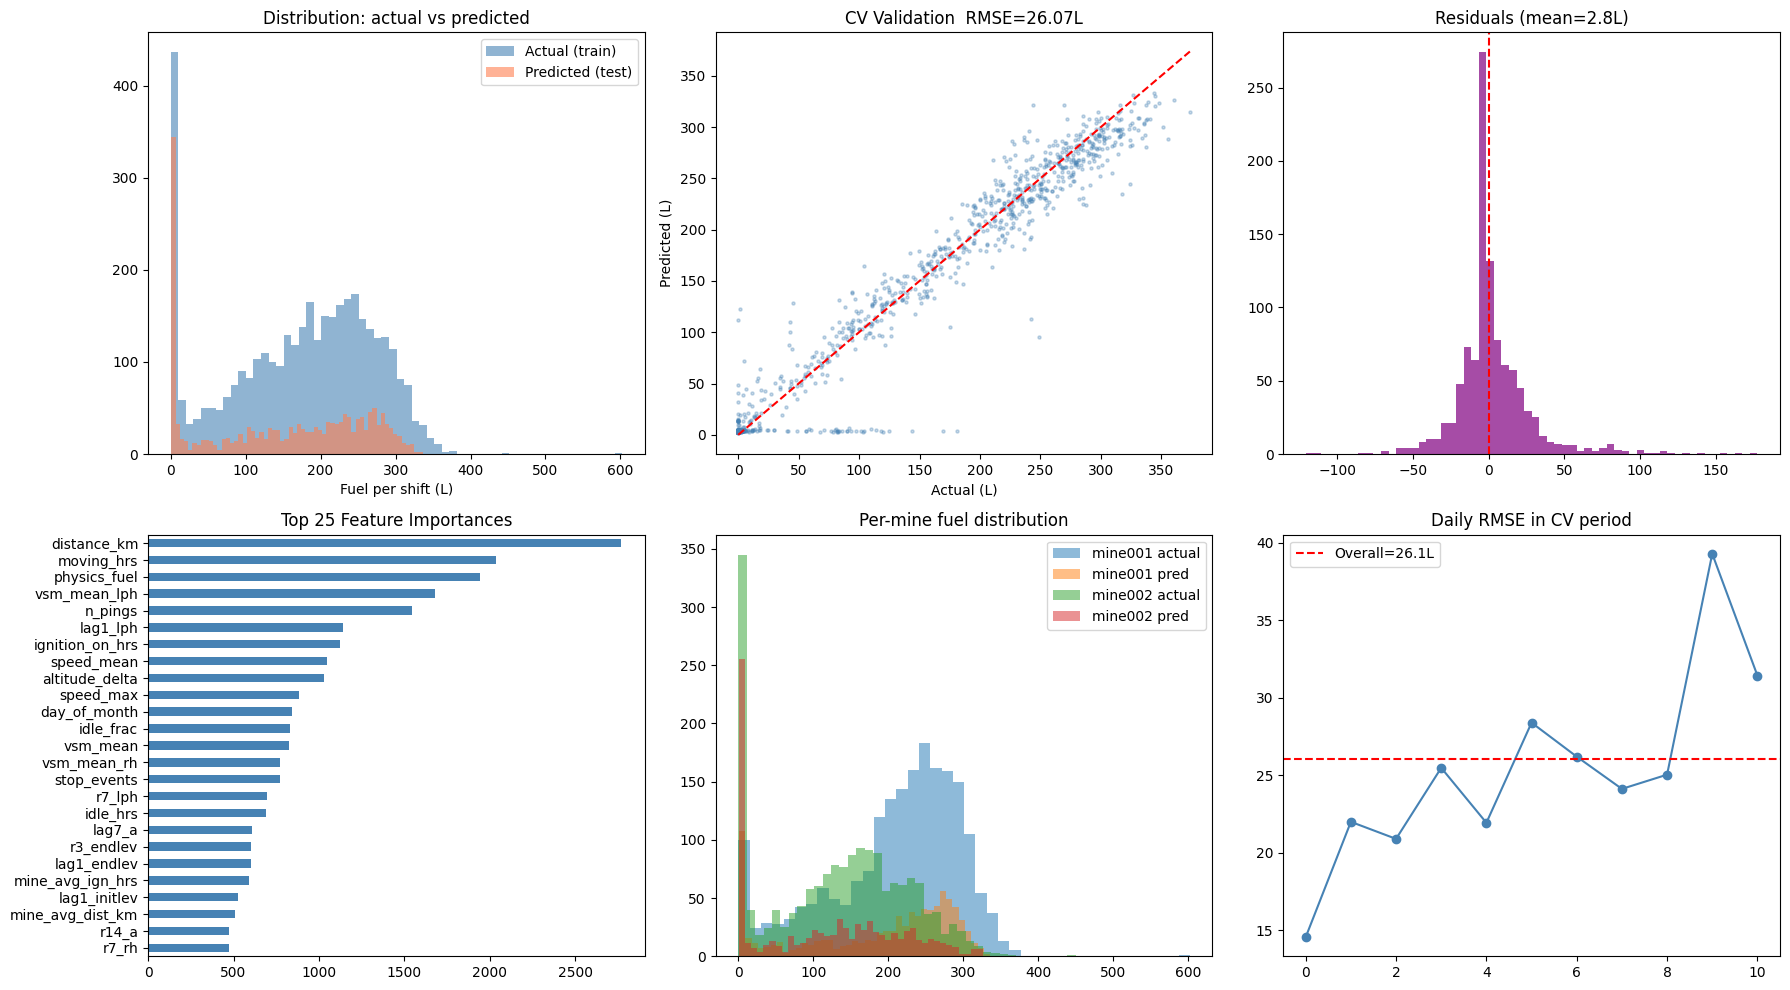


Final CV RMSE (leakage‑free): 26.07 L


In [20]:
# ── 19. DIAGNOSTIC PLOTS ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution comparison
nz_actual = all_smry[all_smry['acons'] > 0]['acons']
nz_pred   = submission[submission['predicted_fuel_litres'] > 0]['predicted_fuel_litres']
axes[0,0].hist(nz_actual, bins=60, alpha=0.6, label='Actual (train)', color='steelblue')
axes[0,0].hist(nz_pred,   bins=60, alpha=0.6, label='Predicted (test)', color='coral')
axes[0,0].set_xlabel('Fuel per shift (L)')
axes[0,0].set_title('Distribution: actual vs predicted')
axes[0,0].legend()

# 2. CV scatter
val_final = np.clip((1-PHYSICS_ALPHA)*val_preds_raw + PHYSICS_ALPHA*physics_val_cv, 0, None)
axes[0,1].scatter(y_val.values, val_final, alpha=0.3, s=5, color='steelblue')
mn, mx = 0, float(y_val.max())
axes[0,1].plot([mn, mx], [mn, mx], 'r--')
axes[0,1].set_xlabel('Actual (L)')
axes[0,1].set_ylabel('Predicted (L)')
rmse_final = np.sqrt(mean_squared_error(y_val, val_final))
axes[0,1].set_title(f'CV Validation  RMSE={rmse_final:.2f}L')

# 3. Residuals
residuals = y_val.values - val_final
axes[0,2].hist(residuals, bins=60, color='purple', alpha=0.7)
axes[0,2].axvline(0, color='red', linestyle='--')
axes[0,2].set_title(f'Residuals (mean={residuals.mean():.1f}L)')

# 4. Feature importance
imp2 = pd.Series(cv_model.feature_importances_, index=FEATURE_COLS)
imp2.sort_values().tail(25).plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Top 25 Feature Importances')

# 5. Per-mine distribution
test_df_plot = test_df.copy()
test_df_plot['pred'] = final_preds
for i, mine in enumerate(['mine001','mine002']):
    enc = i
    sub_act  = all_smry[all_smry['mine_enc']==enc]['acons']
    sub_pred = test_df_plot[test_df_plot['mine_enc']==enc]['pred']
    axes[1,1].hist(sub_act[sub_act>0], bins=40, alpha=0.5, label=f'{mine} actual')
    axes[1,1].hist(sub_pred[sub_pred>0], bins=40, alpha=0.5, label=f'{mine} pred')
axes[1,1].legend()
axes[1,1].set_title('Per-mine fuel distribution')

# 6. Daily RMSE
val_df2 = all_smry.loc[val_mask, ['date']].copy()
val_df2['actual']    = y_val.values
val_df2['predicted'] = val_final
val_df2['error2']    = (val_df2['actual'] - val_df2['predicted'])**2
weekly = val_df2.groupby(val_df2['date'].dt.date)['error2'].mean().apply(np.sqrt)
axes[1,2].plot(range(len(weekly)), weekly.values, marker='o', color='steelblue')
axes[1,2].axhline(rmse_final, color='red', linestyle='--', label=f'Overall={rmse_final:.1f}L')
axes[1,2].set_title('Daily RMSE in CV period')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('diagnostics_v15.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'\nFinal CV RMSE (leakage‑free): {rmse_final:.2f} L')

## ── SECONDARY OUTPUTS ──────────────────────────────────────────────────────────
### S1: Route-Level Fuel Benchmark (per mine × shift)
### S2: Dumper Efficiency Ranking (EWM lph + residual)
### S3: Daily Fuel Consistency Check (predicted vs historical daily totals)


=== Route-Level Fuel Benchmark (per mine × shift) ===
   mine shift  median_lph  mean_lph  median_runhrs  mean_acons  n_active  expected_fuel_L
mine001     A       46.72     48.04           4.98      202.96       716            232.7
mine001     B       46.48     46.04           5.20      209.84       714            241.7
mine001     C       45.74     45.20           5.27      214.66       588            241.0
mine002     A       46.06     49.97           3.38      146.81       518            155.7
mine002     B       45.98     49.34           2.81      121.55       648            129.2
mine002     C       46.11     48.56           3.13      131.45       596            144.3
mine003     A       30.81     31.02           2.94       86.84        18             90.6
mine003     B       31.39     39.35           2.40       78.82        19             75.3
mine003     C       95.30     95.30           0.05        6.74         2              4.8

Saved → route_benchmark.csv


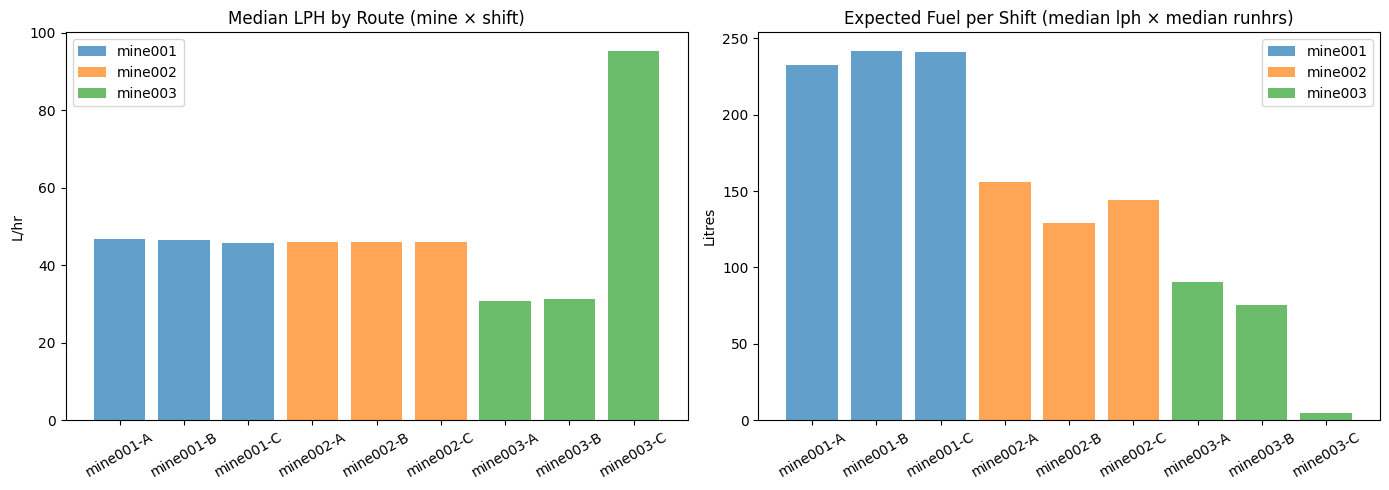

Saved → route_benchmark.png


In [21]:
# ── S1. ROUTE-LEVEL FUEL BENCHMARK ───────────────────────────────────────────
# Median lph per mine × shift from training summary (route-level baseline)
route_bench = all_smry[all_smry['acons'] > 0].groupby(['mine', 'shift']).agg(
    median_lph    = ('lph',    'median'),
    mean_lph      = ('lph',    'mean'),
    median_runhrs = ('runhrs', 'median'),
    mean_acons    = ('acons',  'mean'),
    n_active      = ('acons',  'count'),
).reset_index().round(2)

# Estimate expected fuel per shift = median_lph × median_runhrs
route_bench['expected_fuel_L'] = (route_bench['median_lph'] * route_bench['median_runhrs']).round(1)

print("=== Route-Level Fuel Benchmark (per mine × shift) ===")
print(route_bench.sort_values(['mine', 'shift']).to_string(index=False))

# Save
route_bench.to_csv('route_benchmark.csv', index=False)
print("\nSaved → route_benchmark.csv")

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mine in route_bench['mine'].unique():
    sub = route_bench[route_bench['mine'] == mine]
    axes[0].bar([f"{mine}-{s}" for s in sub['shift']], sub['median_lph'],
                label=mine, alpha=0.7)
axes[0].set_title('Median LPH by Route (mine × shift)')
axes[0].set_ylabel('L/hr')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

for mine in route_bench['mine'].unique():
    sub = route_bench[route_bench['mine'] == mine]
    axes[1].bar([f"{mine}-{s}" for s in sub['shift']], sub['expected_fuel_L'],
                label=mine, alpha=0.7)
axes[1].set_title('Expected Fuel per Shift (median lph × median runhrs)')
axes[1].set_ylabel('Litres')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('route_benchmark.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved → route_benchmark.png")


=== Dumper Efficiency Ranking (active shifts only) ===
vehicle    mine  efficiency_rank  mean_lph  ewm_lph_last  residual  mean_runhrs  mean_acons  pct_active
Dump045 mine003                1     33.14         31.78      1.70         2.65       85.78         1.0
Dump036 mine002                2     40.49         36.26     15.20         2.39      101.86         1.0
Dump044 mine003                3     40.92         47.62    -36.28         2.28       72.22         1.0
Dump032 mine002                4     41.43         50.33    -26.35         3.20      134.49         1.0
Dump034 mine002                5     42.88         55.15    -34.58         2.80      119.97         1.0
Dump012 mine001                6     42.98         45.00     -1.63         1.39       60.94         1.0
Dump035 mine002                7     43.54         41.96      3.85         3.05      131.75         1.0
Dump021 mine001                8     44.18         40.41     19.44         5.23      230.96         1.0
Dump024 m

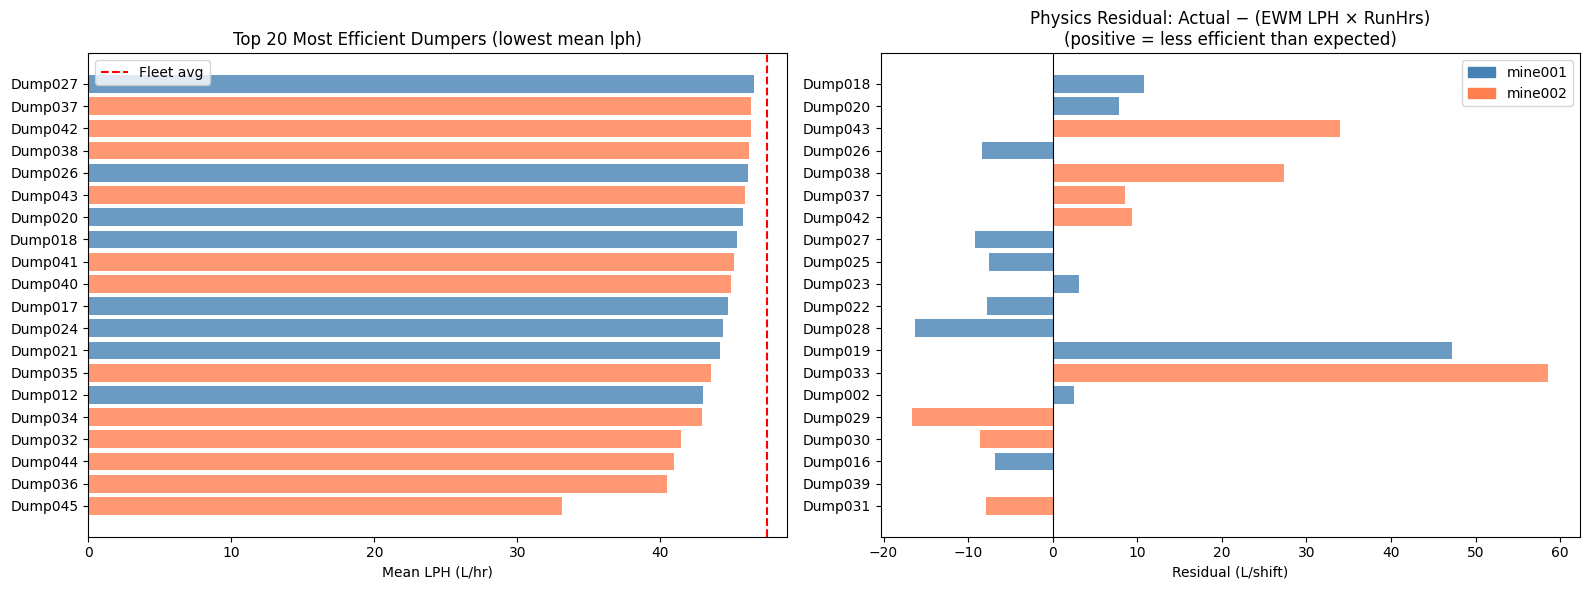

Saved → dumper_efficiency.png


In [22]:
# ── S2. DUMPER EFFICIENCY RANKING ────────────────────────────────────────────
# Per-vehicle efficiency: EWM lph, mean residual from physics baseline,
# activity rate, and overall consumption rank.

active_v = all_smry[all_smry['acons'] > 0].copy()

# EWM lph per vehicle (span=7 shifts, most recent value)
active_v = active_v.sort_values(['vehicle', 'date', 'shift'])
active_v['lph_ewm'] = active_v.groupby('vehicle')['lph'].transform(
    lambda x: x.ewm(span=7, adjust=False).mean()
)

# Per-vehicle summary
veh_eff = active_v.groupby('vehicle').agg(
    mine         = ('mine',    'first'),
    n_active     = ('acons',   'count'),
    mean_lph     = ('lph',     'mean'),
    ewm_lph_last = ('lph_ewm', 'last'),   # most recent EWM lph
    mean_runhrs  = ('runhrs',  'mean'),
    mean_acons   = ('acons',   'mean'),
    pct_active   = ('acons',   lambda x: (x > 0).mean()),
).reset_index()

# Physics residual: actual - (ign_hrs * ewm_lph) -- using runhrs as proxy for ign_hrs
# In training smry we have runhrs directly
veh_eff['physics_pred'] = veh_eff['ewm_lph_last'] * veh_eff['mean_runhrs']
veh_eff['residual']     = (veh_eff['mean_acons'] - veh_eff['physics_pred']).round(2)

# Efficiency rank: lower lph = more efficient
veh_eff['efficiency_rank'] = veh_eff['mean_lph'].rank(method='min').astype(int)
veh_eff = veh_eff.sort_values('mean_lph').round(2)

print("=== Dumper Efficiency Ranking (active shifts only) ===")
print(veh_eff[['vehicle','mine','efficiency_rank','mean_lph','ewm_lph_last',
               'residual','mean_runhrs','mean_acons','pct_active']].to_string(index=False))

veh_eff.to_csv('dumper_efficiency.csv', index=False)
print("\nSaved → dumper_efficiency.csv")

# Plot: efficiency ranking
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_n = veh_eff.nsmallest(20, 'mean_lph')
bot_n = veh_eff.nlargest(20, 'mean_lph')
colors_top = ['steelblue' if m == 'mine001' else 'coral' for m in top_n['mine']]
colors_bot = ['steelblue' if m == 'mine001' else 'coral' for m in bot_n['mine']]

axes[0].barh(top_n['vehicle'], top_n['mean_lph'], color=colors_top, alpha=0.8)
axes[0].set_title('Top 20 Most Efficient Dumpers (lowest mean lph)')
axes[0].set_xlabel('Mean LPH (L/hr)')
axes[0].axvline(veh_eff['mean_lph'].mean(), color='red', linestyle='--', label='Fleet avg')
axes[0].legend()

axes[1].barh(bot_n['vehicle'], bot_n['residual'], color=colors_bot, alpha=0.8)
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_title('Physics Residual: Actual − (EWM LPH × RunHrs)\n(positive = less efficient than expected)')
axes[1].set_xlabel('Residual (L/shift)')

import matplotlib.patches as mpatches
p1 = mpatches.Patch(color='steelblue', label='mine001')
p2 = mpatches.Patch(color='coral', label='mine002')
axes[1].legend(handles=[p1, p2])

plt.tight_layout()
plt.savefig('dumper_efficiency.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved → dumper_efficiency.png")


=== Daily Fuel Consistency Check ===
Total test vehicle-days: 579
Flagged (>30% deviation from historical daily mean): 277

Top 15 flagged vehicle-days:
vehicle       date  daily_pred_L  hist_daily_mean  deviation_pct
Dump036 2026-02-27    685.817061       181.306800          276.7
Dump036 2026-02-23    667.320906       181.306800          266.6
Dump036 2026-02-28    644.681210       181.306800          254.2
Dump039 2026-02-21    754.835927       243.580196          209.0
Dump041 2026-01-21    607.630742       206.278400          193.6
Dump036 2026-02-26    514.862215       181.306800          183.0
Dump036 2026-02-24    507.809260       181.306800          179.1
Dump036 2026-02-22    500.289564       181.306800          175.0
Dump036 2026-02-21    492.817413       181.306800          170.9
Dump041 2026-01-22    551.799452       206.278400          166.7
Dump040 2026-01-31    618.085923       231.481000          166.3
Dump042 2026-01-21    620.112290       237.433469          160.5
Du

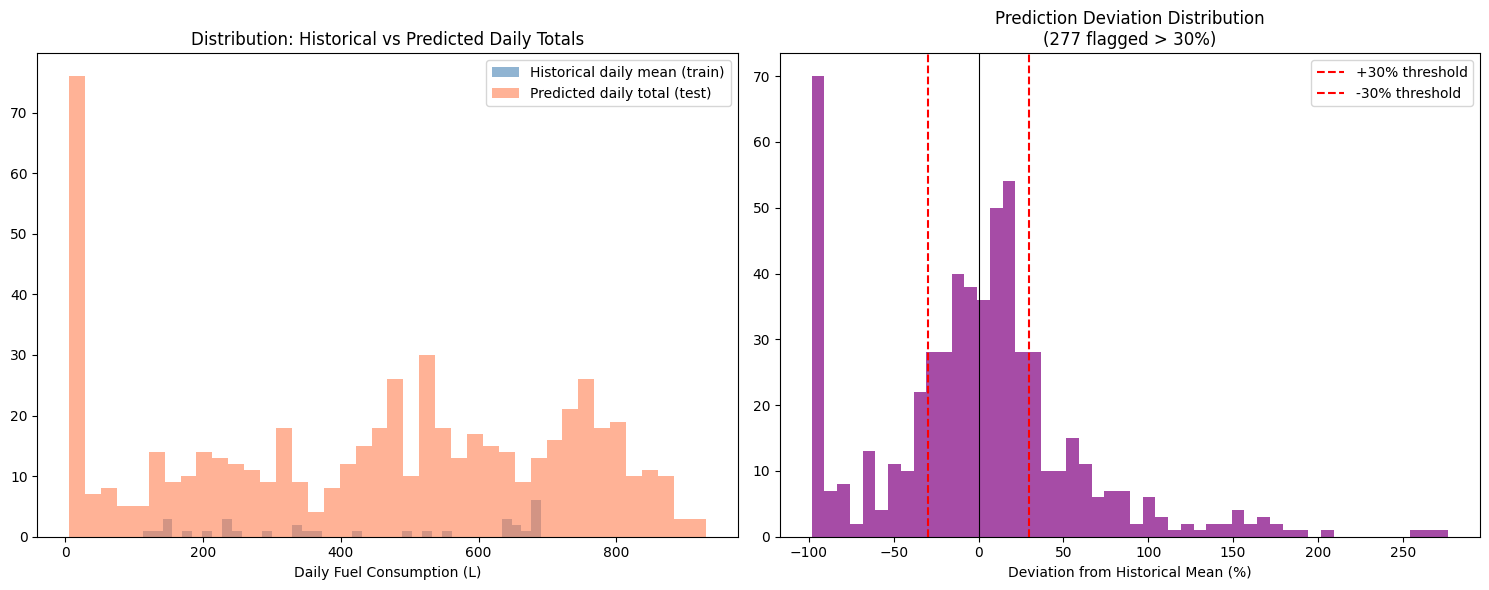

Saved → daily_consistency.png


In [23]:
# ── S3. DAILY FUEL CONSISTENCY CHECK ─────────────────────────────────────────
# Aggregate shift-level predictions to daily totals per vehicle,
# then compare with training actuals to flag large deviations.

submission_full = id_mapping[['id', 'vehicle', 'date', 'shift']].copy()
submission_full['predicted_fuel_litres'] = final_preds
submission_full['date'] = pd.to_datetime(submission_full['date'])

# Daily predicted totals (sum across A+B+C shifts)
daily_pred = submission_full.groupby(['vehicle', 'date']).agg(
    daily_pred_L = ('predicted_fuel_litres', 'sum'),
    shifts_pred  = ('predicted_fuel_litres', 'count'),
    n_nonzero    = ('predicted_fuel_litres', lambda x: (x > 0).sum()),
).reset_index()

# Training daily actuals (sum across shifts)
all_smry_cp = all_smry.copy()
all_smry_cp['date'] = pd.to_datetime(all_smry_cp['date'])
daily_actual = all_smry_cp.groupby(['vehicle', 'date']).agg(
    daily_actual_L = ('acons', 'sum'),
).reset_index()

# Per-vehicle historical daily mean from training
veh_daily_mean = daily_actual[daily_actual['daily_actual_L'] > 0].groupby('vehicle').agg(
    hist_daily_mean = ('daily_actual_L', 'mean'),
    hist_daily_std  = ('daily_actual_L', 'std'),
).reset_index()

# Flag predictions that deviate > 30% from historical mean
daily_pred = daily_pred.merge(veh_daily_mean, on='vehicle', how='left')
daily_pred['deviation_pct'] = ((daily_pred['daily_pred_L'] - daily_pred['hist_daily_mean'])
                                / (daily_pred['hist_daily_mean'] + 1) * 100).round(1)
daily_pred['flag'] = daily_pred['deviation_pct'].abs() > 30

print("=== Daily Fuel Consistency Check ===")
print(f"Total test vehicle-days: {len(daily_pred)}")
print(f"Flagged (>30% deviation from historical daily mean): {daily_pred['flag'].sum()}")
print()
flagged = daily_pred[daily_pred['flag']].sort_values('deviation_pct', key=abs, ascending=False)
print("Top 15 flagged vehicle-days:")
print(flagged[['vehicle','date','daily_pred_L','hist_daily_mean','deviation_pct']].head(15).to_string(index=False))

daily_pred.to_csv('daily_consistency.csv', index=False)
print("\nSaved → daily_consistency.csv")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histogram of daily predicted totals vs historical
hist_vals = veh_daily_mean['hist_daily_mean']
axes[0].hist(hist_vals, bins=40, alpha=0.6, label='Historical daily mean (train)', color='steelblue')
axes[0].hist(daily_pred[daily_pred['daily_pred_L'] > 0]['daily_pred_L'],
             bins=40, alpha=0.6, label='Predicted daily total (test)', color='coral')
axes[0].set_xlabel('Daily Fuel Consumption (L)')
axes[0].set_title('Distribution: Historical vs Predicted Daily Totals')
axes[0].legend()

# 2. Deviation distribution
axes[1].hist(daily_pred['deviation_pct'].dropna(), bins=50, color='purple', alpha=0.7)
axes[1].axvline(30,  color='red', linestyle='--', label='+30% threshold')
axes[1].axvline(-30, color='red', linestyle='--', label='-30% threshold')
axes[1].axvline(0,   color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Deviation from Historical Mean (%)')
axes[1].set_title(f'Prediction Deviation Distribution\n({daily_pred["flag"].sum()} flagged > 30%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('daily_consistency.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved → daily_consistency.png")


In [24]:
# ── S4. SUMMARY EXPORT: All Secondary Outputs ────────────────────────────────
print("\n========== SECONDARY OUTPUT SUMMARY ==========")
print(f"S1 route_benchmark.csv    → {len(route_bench)} rows (mine × shift benchmarks)")
print(f"S2 dumper_efficiency.csv  → {len(veh_eff)} vehicles ranked by efficiency")
print(f"S3 daily_consistency.csv  → {len(daily_pred)} vehicle-days; {daily_pred['flag'].sum()} flagged")
print("==============================================")

# Colab download
try:
    from google.colab import files
    for fname in ['route_benchmark.csv', 'dumper_efficiency.csv', 'daily_consistency.csv',
                  'route_benchmark.png', 'dumper_efficiency.png', 'daily_consistency.png']:
        files.download(fname)
        print(f"Downloading {fname}...")
except:
    print("Not in Colab — files are saved in current directory.")



========== SECONDARY OUTPUT SUMMARY ==========
S1 route_benchmark.csv    → 9 rows (mine × shift benchmarks)
S2 dumper_efficiency.csv  → 32 vehicles ranked by efficiency
S3 daily_consistency.csv  → 579 vehicle-days; 277 flagged


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# ── 20. DOWNLOAD ──────────────────────────────────────────────────────────────
try:
    from google.colab import files
    files.download(SUBMISSION_PATH)
    files.download('diagnostics_v15.png')
except:
    print('Not in Colab — download files manually')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>